# Clasificación del dataset Iris

En este notebook se comparan tres clasificadores supervisados:

- **LDA** — Linear Discriminant Analysis.
- **KNN** — K-Nearest Neighbors con $k=3$.
- **Decision Tree** — Árbol de decisión.

El conjunto se divide de forma estratificada:

- **70 % para entrenamiento**.
- **30 % para prueba**.

Para visualizar fronteras de decisión en dos dimensiones se utilizan las variables `petal length (cm)` y `petal width (cm)`. Las métricas se calculan con esos mismos modelos y variables, por lo que la comparación visual y numérica es consistente.

## 1. Instalación de dependencias

Ejecuta esta celda solamente si `scikit-learn` no está instalado. Después de instalarlo puede ser necesario reiniciar el kernel.

In [15]:
%pip install -q scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importar librerías

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42


## 3. Cargar y explorar Iris

Iris contiene 150 flores de tres especies. Cada especie tiene 50 observaciones.

In [17]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = [iris.target_names[value] for value in iris.target]

print("Dimensiones:", df.shape)
print("Clases:", list(iris.target_names))
print("\nCantidad por especie:")
print(df["species"].value_counts())
display(df.head())


Dimensiones: (150, 6)
Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Cantidad por especie:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 4. Selección de variables y visualización

Las dos medidas del pétalo separan claramente las especies y permiten dibujar las fronteras directamente, sin recurrir a una proyección que altere su interpretación.

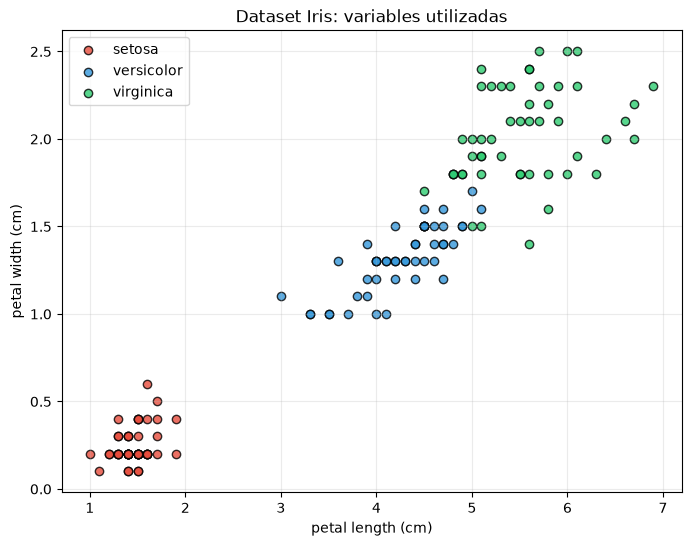

In [18]:
feature_indices = [2, 3]
feature_names = [iris.feature_names[index] for index in feature_indices]

X = iris.data[:, feature_indices]
y = iris.target

colors = ["#e74c3c", "#3498db", "#2ecc71"]
plt.figure(figsize=(8, 6))
for class_index, (class_name, color) in enumerate(zip(iris.target_names, colors)):
    mask = y == class_index
    plt.scatter(X[mask, 0], X[mask, 1], label=class_name,
                color=color, edgecolor="black", alpha=0.8)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Dataset Iris: variables utilizadas")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 5. División 70 % entrenamiento y 30 % prueba

`stratify=y` conserva la misma proporción de las tres especies en ambos subconjuntos.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)

print(f"Total: {len(X)} observaciones")
print(f"Entrenamiento: {len(X_train)} observaciones ({len(X_train)/len(X):.0%})")
print(f"Prueba: {len(X_test)} observaciones ({len(X_test)/len(X):.0%})")

print("\nDistribución en entrenamiento:", np.bincount(y_train))
print("Distribución en prueba:       ", np.bincount(y_test))


Total: 150 observaciones
Entrenamiento: 105 observaciones (70%)
Prueba: 45 observaciones (30%)

Distribución en entrenamiento: [35 35 35]
Distribución en prueba:        [15 15 15]


## 6. Definir y entrenar los clasificadores

LDA y KNN incluyen estandarización dentro de un `Pipeline`. El árbol no necesita estandarización y se limita a profundidad 4 para evitar una frontera excesivamente fragmentada.

In [20]:
models = {
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LinearDiscriminantAnalysis()),
    ]),
    "KNN (k=3)": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=3)),
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=2,
        random_state=SEED,
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} entrenado correctamente")


LDA entrenado correctamente
KNN (k=3) entrenado correctamente
Decision Tree entrenado correctamente


## 7. Métricas de clasificación

Se reportan métricas macro, dando el mismo peso a cada especie:

- **Accuracy**: proporción total de predicciones correctas.
- **Precision**: qué tan confiables son las predicciones de cada clase.
- **Recall**: qué proporción de cada especie fue detectada.
- **F1-score**: balance entre precision y recall.

In [21]:
predictions = {}
metric_rows = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    metric_rows.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    })

metrics_df = pd.DataFrame(metric_rows).set_index("Modelo")
display(metrics_df.round(4))


,Accuracy,Precision macro,Recall macro,F1 macro
Modelo,,,,
LDA,0.9111,0.9155,0.9111,0.9107
KNN (k=3),0.9333,0.9345,0.9333,0.9333
Decision Tree,0.8889,0.8981,0.8889,0.8878


### Reporte detallado por especie

In [22]:
for name, y_pred in predictions.items():
    print("=" * 65)
    print(name)
    print("=" * 65)
    print(classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names,
        digits=4,
        zero_division=0,
    ))


LDA
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     0.8235    0.9333    0.8750        15
   virginica     0.9231    0.8000    0.8571        15

    accuracy                         0.9111        45
   macro avg     0.9155    0.9111    0.9107        45
weighted avg     0.9155    0.9111    0.9107        45

KNN (k=3)
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     0.8750    0.9333    0.9032        15
   virginica     0.9286    0.8667    0.8966        15

    accuracy                         0.9333        45
   macro avg     0.9345    0.9333    0.9333        45
weighted avg     0.9345    0.9333    0.9333        45

Decision Tree
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     0.7778    0.9333    0.8485        15
   virginica     0.9167    0.7333    0.8148    

## 8. Matrices de confusión

La diagonal contiene los aciertos. Los valores fuera de la diagonal muestran qué especies fueron confundidas.

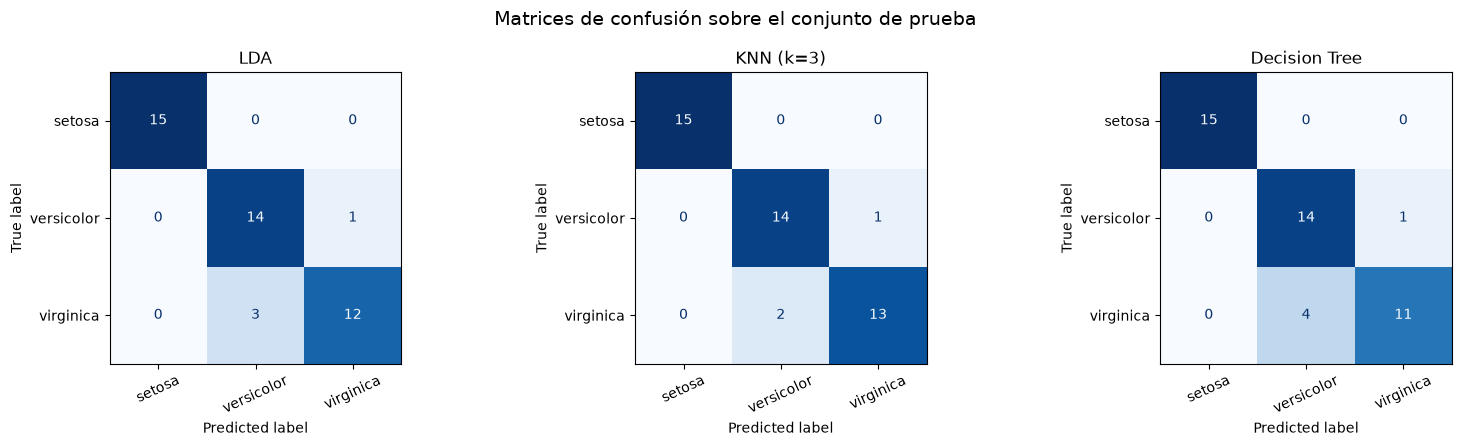

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=iris.target_names,
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Matrices de confusión sobre el conjunto de prueba", fontsize=14)
plt.tight_layout()
plt.show()


## 9. Fronteras de decisión

El color de fondo indica la clase que cada modelo asignaría a cualquier combinación de largo y ancho del pétalo. Los puntos circulares corresponden al entrenamiento y las estrellas al conjunto de prueba.

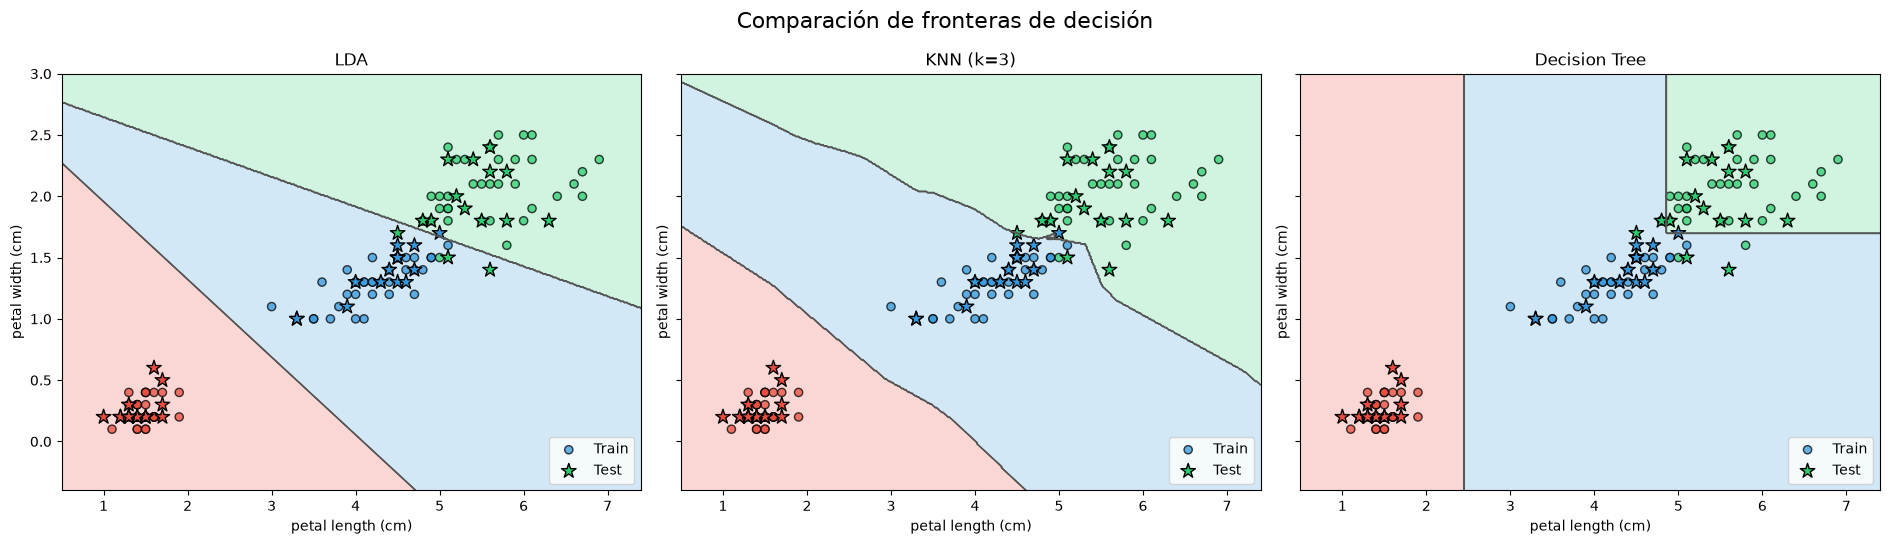

In [24]:
def plot_decision_boundary(ax, model, name, X_train, y_train, X_test, y_test):
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 450),
        np.linspace(y_min, y_max, 350),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    surface = model.predict(grid).reshape(xx.shape)

    background_cmap = ListedColormap(["#f7b7b2", "#aed6f1", "#abebc6"])
    point_cmap = ListedColormap(colors)
    ax.contourf(xx, yy, surface, alpha=0.55, cmap=background_cmap)
    ax.contour(xx, yy, surface, colors="#555555", linewidths=0.7)

    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=point_cmap,
               edgecolor="black", s=35, alpha=0.75, label="Train")
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=point_cmap,
               edgecolor="black", marker="*", s=120, label="Test")
    ax.set_title(name)
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.legend(loc="lower right")


fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), sharex=True, sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    plot_decision_boundary(ax, model, name, X_train, y_train, X_test, y_test)

plt.suptitle("Comparación de fronteras de decisión", fontsize=16)
plt.tight_layout()
plt.show()


## 10. Comparación de las fronteras

- **LDA** produce fronteras lineales. Es simple y fácil de interpretar.
- **KNN (k=3)** crea fronteras locales e irregulares según los vecinos cercanos.
- **Decision Tree** divide el espacio mediante cortes horizontales y verticales.

Las estrellas que aparecen sobre un color de fondo diferente al color de su especie representan errores sobre el conjunto de prueba.

## 11. Visualizar el árbol de decisión

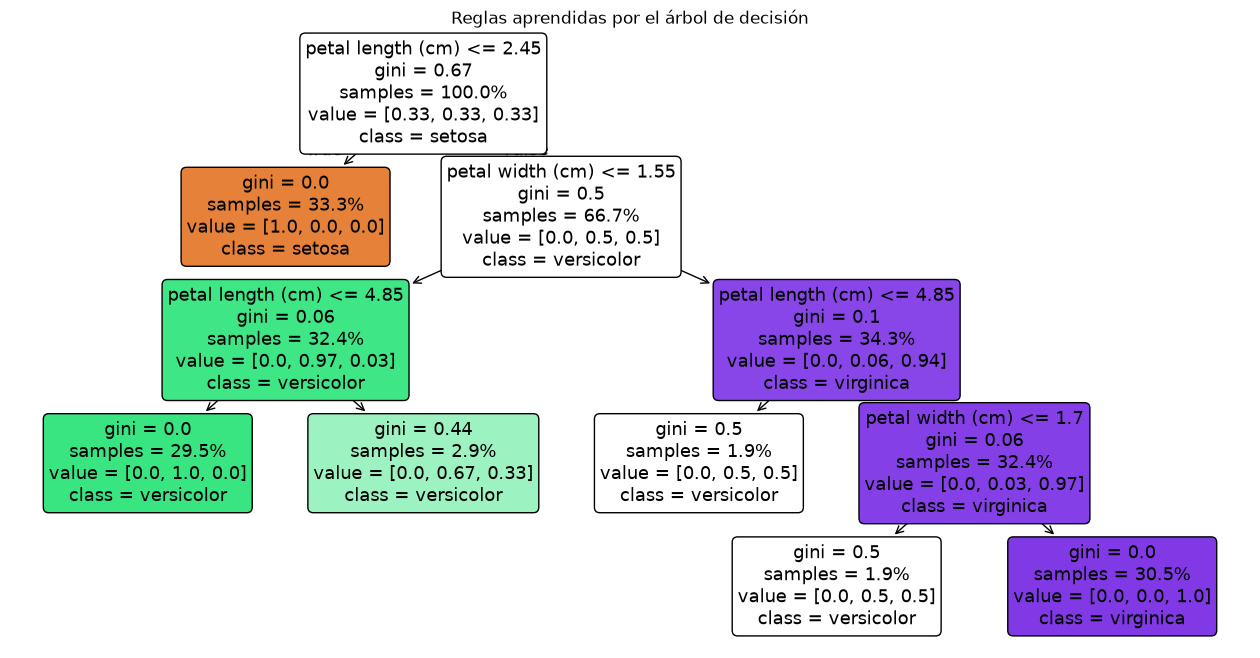

In [25]:
tree_model = models["Decision Tree"]

plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
)
plt.title("Reglas aprendidas por el árbol de decisión")
plt.show()


## 12. Seleccionar el mejor modelo

In [26]:
best_model_name = metrics_df["F1 macro"].idxmax()
best_f1 = metrics_df.loc[best_model_name, "F1 macro"]
best_accuracy = metrics_df.loc[best_model_name, "Accuracy"]

print(f"Mejor modelo según F1 macro: {best_model_name}")
print(f"F1 macro: {best_f1:.4f}")
print(f"Accuracy: {best_accuracy:.4f}")


Mejor modelo según F1 macro: KNN (k=3)
F1 macro: 0.9333
Accuracy: 0.9333


## Conclusiones

1. La separación estratificada garantiza 105 ejemplos de entrenamiento y 45 de prueba, con igual representación de las especies.
2. Las variables del pétalo permiten separar completamente `setosa`; la mayor dificultad está entre `versicolor` y `virginica`.
3. LDA impone fronteras rectas, KNN responde a la estructura local y el árbol utiliza reglas rectangulares.
4. Accuracy, precision, recall y F1 deben evaluarse en conjunto; no basta con observar únicamente los datos de entrenamiento.
5. El mejor modelo se selecciona automáticamente mediante el F1 macro obtenido sobre el conjunto de prueba.